# 📊 DS 4226 — Data Challenge | Homework Assignment 1
**Instructor:** Bro. Ipyana Issah Mwaisekwa  
**Course:** DS 4226 – Data Challenge  
**Institution:** Mbeya University of Science and Technology (MUST)

---

## 🎯 Assignment Overview

This notebook covers all four tasks of Homework Assignment 1:

| # | Task | Status |
|---|------|--------|
| 1 | Sign up for Kaggle / DrivenData | 🔗 Instructions below |
| 2 | Clean the WFP Food Prices Nigeria dataset | 🐍 Fully coded |
| 3 | Submit via GitHub | 📁 Step-by-step guide |
| 4 | Convert a vague problem into a SMART data question | 🧠 Framework applied |

---


## ✅ Part 1 — Sign Up for Kaggle & DrivenData

### Kaggle
1. Go to [https://www.kaggle.com](https://www.kaggle.com)
2. Click **Register** → sign up with Google or email
3. Complete the **Python Micro-Course**: [kaggle.com/learn/python](https://www.kaggle.com/learn/python)

### DrivenData
1. Go to [https://www.drivendata.org](https://www.drivendata.org)
2. Click **Sign Up** → create a free account
3. Browse social impact challenges (e.g., poverty mapping)

> 💡 **Tip:** Use the same email for both platforms. Take a screenshot of your profile page as proof of registration.

---


## 🧹 Part 2 — Clean the WFP Food Prices Nigeria Dataset

We will walk through a complete, professional data cleaning pipeline using Python.  
Each step is explained with comments and markdown so you understand *why* each action is taken.

### Step 2.1 — Install & Import Libraries


In [31]:
# Install any missing libraries (uncomment if needed)
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Plot styling
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9fa",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.family":      "DejaVu Sans",
})

print("✅ All libraries imported successfully!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")


✅ All libraries imported successfully!
   pandas  : 3.0.2
   numpy   : 2.4.4


### Step 2.2 — Load the Dataset

The WFP (World Food Programme) Food Prices dataset tracks commodity prices across markets in Nigeria.  
We load it directly from the **Humanitarian Data Exchange (HDX)** portal.


In [32]:
# ── Load from local file ─────────────────────────────────────
df_raw = pd.read_csv("Data/wfp_food_prices_nga.csv")

print(f"✅ Dataset loaded!")
print(f"   Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumn names:")
for col in df_raw.columns:
    print(f"   • {col}")

✅ Dataset loaded!
   Shape  : 56,798 rows × 16 columns

Column names:
   • date
   • admin1
   • admin2
   • market
   • market_id
   • latitude
   • longitude
   • category
   • commodity
   • commodity_id
   • unit
   • priceflag
   • pricetype
   • currency
   • price
   • usdprice


In [33]:
# Preview the first few rows
df_raw.head(10)


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,175.92,1.54
1,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Millet,73,KG,actual,Wholesale,NGN,150.18,1.31
2,2002-01-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,pulses and nuts,Beans (niebe),120,KG,actual,Wholesale,NGN,196.87,1.72
3,2002-01-15,Sokoto,Gada,Illela (CBM),1037,13.64,5.28,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,153.35,1.34
4,2002-01-15,Sokoto,Gada,Illela (CBM),1037,13.64,5.28,cereals and tubers,Rice (imported),64,KG,actual,Wholesale,NGN,337.59,2.95
5,2002-02-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,169.76,1.42
6,2002-02-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Rice (imported),64,KG,actual,Wholesale,NGN,381.97,3.19
7,2002-02-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Sorghum,65,KG,actual,Wholesale,NGN,159.15,1.33
8,2002-02-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,pulses and nuts,Beans (niebe),120,KG,actual,Wholesale,NGN,201.59,1.68
9,2002-03-15,Katsina,Jibia,Jibia (CBM),1038,13.08,7.24,cereals and tubers,Maize,51,KG,actual,Wholesale,NGN,181.94,1.56


In [34]:
# Check data types
df_raw.dtypes


date                str
admin1              str
admin2              str
market              str
market_id         int64
latitude        float64
longitude       float64
category            str
commodity           str
commodity_id      int64
unit                str
priceflag           str
pricetype           str
currency            str
price           float64
usdprice        float64
dtype: object

### Step 2.3 — Normalise Column Names

Raw column names often have mixed case, spaces, or special characters.  
We standardise them to `lowercase_with_underscores` for consistent access in code.


In [35]:
df = df_raw.copy()  # Always work on a copy — preserve the original

df.columns = (
    df.columns
    .str.strip()        # remove leading/trailing spaces
    .str.lower()        # all lowercase
    .str.replace(" ", "_", regex=False)   # spaces → underscores
    .str.replace(r"[^\w]", "_", regex=True) # any non-word char → underscore
)

print("✅ Column names normalised:")
print(df.columns.tolist())


✅ Column names normalised:
['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']


### Step 2.4 — Identify & Handle Missing Values

Missing data is one of the most common issues in real-world datasets.  
We first *audit* what's missing, then decide the best strategy per column.


In [36]:
# ── Audit missing values ─────────────────────────────────────
missing      = df.isnull().sum()
missing_pct  = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %":     missing_pct
}).sort_values("Missing %", ascending=False)

print("Missing Value Report:")
print(missing_report[missing_report["Missing Count"] > 0].to_string())


Missing Value Report:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [37]:
print(df.columns.tolist())

['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']


In [38]:
# ── Strategy ─────────────────────────────────────────────────
# 1. Drop rows where 'price' is missing  → price is our key variable
before = len(df)
df.dropna(subset=["price"], inplace=True)
dropped = before - len(df)
print(f"Dropped {dropped} rows with missing 'price'  ({dropped/before*100:.2f}% of data)")

# 2. Fill missing text columns with 'Unknown'
text_cols = df.select_dtypes(include="object").columns.tolist()
df[text_cols] = df[text_cols].fillna("Unknown")

# 3. Fill missing numeric columns with column median (robust to outliers)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    median_val = df[col].median()
    filled = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    if filled > 0:
        print(f"Filled {filled} missing values in '{col}' with median = {median_val:.4f}")

print(f"\n✅ Missing value handling complete. Remaining nulls: {df.isnull().sum().sum()}")


Dropped 0 rows with missing 'price'  (0.00% of data)

✅ Missing value handling complete. Remaining nulls: 0


### Step 2.5 — Fix Data Types

Columns loaded as `object` (string) may actually be dates or numbers.  
Correct types unlock proper sorting, arithmetic, and time-series operations.


In [39]:
# ── Parse date column ────────────────────────────────────────
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(f"Date range: {df['date'].min().date()}  →  {df['date'].max().date()}")

# ── Ensure price columns are truly numeric ────────────────────
for col in ["price", "usdprice"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        print(f"'{col}' → numeric  ✅  (min={df[col].min():.2f}, max={df[col].max():.2f})")

print(f"\n✅ Data types fixed.")
df.dtypes


Date range: 2002-01-15  →  2026-04-15
'price' → numeric  ✅  (min=1.00, max=138000.00)
'usdprice' → numeric  ✅  (min=0.00, max=453.17)

✅ Data types fixed.


date            datetime64[us]
admin1                     str
admin2                     str
market                     str
market_id                int64
latitude               float64
longitude              float64
category                   str
commodity                  str
commodity_id             int64
unit                       str
priceflag                  str
pricetype                  str
currency                   str
price                  float64
usdprice               float64
dtype: object

### Step 2.6 — Remove Duplicates

Duplicate records inflate counts, skew averages, and corrupt model training.


In [40]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

df.drop_duplicates(inplace=True)
print(f"✅ Duplicates removed. Shape: {df.shape}")


Duplicate rows found: 0
✅ Duplicates removed. Shape: (56798, 16)


### Step 2.7 — Standardise Text Values

Inconsistent capitalisation creates phantom duplicates:  
e.g., `"lagos"`, `"Lagos"`, and `"LAGOS"` all mean the same market.  
We apply **Title Case** and strip whitespace uniformly.


In [41]:
# ── Standardise text columns ─────────────────────────────────
# Re-derive text_cols safely — only genuine string columns
text_cols = [
    col for col in df.select_dtypes(include="object").columns
    if col in df.columns
]

for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print("✅ Text columns standardised to Title Case.")

# Sample check
if "market" in df.columns:
    print(f"\nUnique markets ({df['market'].nunique()} total):")
    print(df["market"].value_counts().head(10).to_string())

✅ Text columns standardised to Title Case.

Unique markets (68 total):
market
Potiskum         2534
Dawanau          1666
Maiduguri        1618
Ibadan           1582
Budum            1579
Geidam           1541
Gombe            1526
Monday           1524
Yunusari         1520
Bade (Gashua)    1500


### Step 2.8 — Detect & Handle Outliers (IQR Method)

The **Interquartile Range (IQR)** method flags values far outside the middle 50% of data.  
- Values below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` are considered outliers.  
- We **cap** them (Winsorisation) rather than delete — preserving data volume.


In [42]:
Q1  = df["price"].quantile(0.25)
Q3  = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (df["price"] < lower) | (df["price"] > upper)
n_outliers   = outlier_mask.sum()

print(f"Q1            : {Q1:.2f}")
print(f"Q3            : {Q3:.2f}")
print(f"IQR           : {IQR:.2f}")
print(f"Lower bound   : {lower:.2f}")
print(f"Upper bound   : {upper:.2f}")
print(f"Outliers found: {n_outliers} ({n_outliers/len(df)*100:.2f}% of data)")

# Cap outliers — stores result in a new column to preserve originals
df["price_cleaned"] = df["price"].clip(lower=lower, upper=upper)
print(f"\n✅ Outliers capped. 'price_cleaned' column created.")


Q1            : 265.00
Q3            : 3900.00
IQR           : 3635.00
Lower bound   : -5187.50
Upper bound   : 9352.50
Outliers found: 9458 (16.65% of data)

✅ Outliers capped. 'price_cleaned' column created.


### Step 2.9 — Feature Engineering

We extract **year** and **month** from the date column.  
These are useful for trend analysis and seasonal patterns.


In [43]:
df["year"]    = df["date"].dt.year
df["month"]   = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")   # e.g., "Jan", "Feb"

print("✅ New features added: 'year', 'month', 'month_name'")
df[["date", "year", "month", "month_name"]].head(8)


✅ New features added: 'year', 'month', 'month_name'


,date,year,month,month_name
0,2002-01-15,2002,1,Jan
1,2002-01-15,2002,1,Jan
2,2002-01-15,2002,1,Jan
3,2002-01-15,2002,1,Jan
4,2002-01-15,2002,1,Jan
5,2002-02-15,2002,2,Feb
6,2002-02-15,2002,2,Feb
7,2002-02-15,2002,2,Feb


### Step 2.10 — Summary Statistics

Always inspect the cleaned dataset before moving to analysis.


In [44]:
print("=" * 55)
print("CLEANED DATASET — SUMMARY")
print("=" * 55)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print(f"\nNumerical Summary:")
df[["price", "price_cleaned", "usdprice"]].describe().round(2)


CLEANED DATASET — SUMMARY
Rows    : 56,798
Columns : 20

Numerical Summary:


,price,price_cleaned,usdprice
count,56798.00,56798.00,56798.00
mean,5030.09,2657.72,14.47
std,10070.45,3426.99,29.57
min,1.00,1.00,0.00
25%,265.00,265.00,0.71
50%,868.00,868.00,1.74
75%,3900.00,3900.00,4.03
max,138000.00,9352.50,453.17


In [45]:
# Commodity frequency
if "commodity" in df.columns:
    print("Top 10 Commodities:")
    print(df["commodity"].value_counts().head(10).to_string())


Top 10 Commodities:
commodity
Millet             3237
Rice (Imported)    2978
Rice (Local)       2728
Yam                2532
Oil (Palm)         2465
Sorghum            1682
Maize (White)      1574
Sorghum (White)    1554
Sorghum (Brown)    1403
Cowpeas (White)    1397


### Step 2.11 — Exploratory Visualisations

Good visualisations are essential for communicating your findings — a core skill in DS 4226.


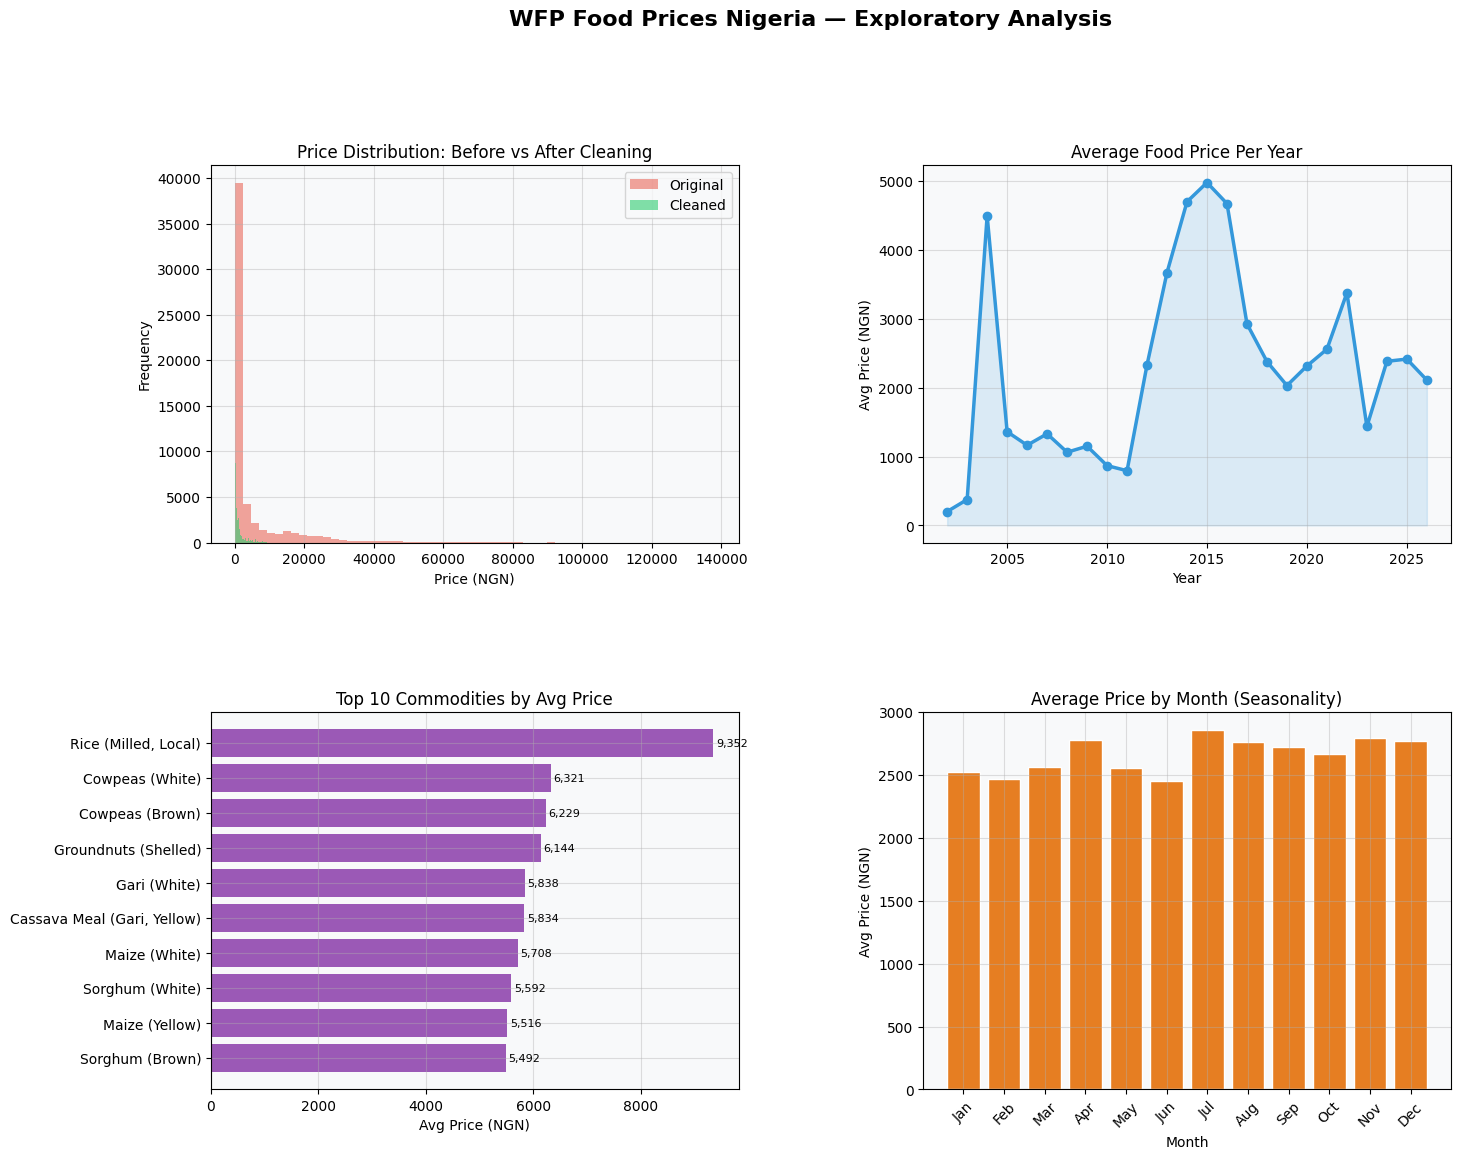


✅ Plots saved as 'wfp_nigeria_analysis.png'


In [46]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("WFP Food Prices Nigeria — Exploratory Analysis", fontsize=16, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Price distribution before vs after cleaning ──────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df["price"],         bins=60, alpha=0.5, color="#e74c3c", label="Original")
ax1.hist(df["price_cleaned"], bins=60, alpha=0.6, color="#2ecc71", label="Cleaned")
ax1.set_title("Price Distribution: Before vs After Cleaning")
ax1.set_xlabel("Price (NGN)")
ax1.set_ylabel("Frequency")
ax1.legend()

# ── Plot 2: Average price per year ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
yearly = df.groupby("year")["price_cleaned"].mean()
ax2.plot(yearly.index, yearly.values, marker="o", color="#3498db", linewidth=2.5)
ax2.fill_between(yearly.index, yearly.values, alpha=0.15, color="#3498db")
ax2.set_title("Average Food Price Per Year")
ax2.set_xlabel("Year")
ax2.set_ylabel("Avg Price (NGN)")

# ── Plot 3: Top 10 commodities by average price ──────────────
ax3 = fig.add_subplot(gs[1, 0])
if "commodity" in df.columns:
    top_comm = (
        df.groupby("commodity")["price_cleaned"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    bars = ax3.barh(top_comm.index[::-1], top_comm.values[::-1], color="#9b59b6")
    ax3.set_title("Top 10 Commodities by Avg Price")
    ax3.set_xlabel("Avg Price (NGN)")
    for bar, val in zip(bars, top_comm.values[::-1]):
        ax3.text(val + 50, bar.get_y() + bar.get_height()/2,
                 f"{val:,.0f}", va="center", fontsize=8)

# ── Plot 4: Monthly average price (seasonality) ──────────────
ax4 = fig.add_subplot(gs[1, 1])
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby("month_name")["price_cleaned"].mean().reindex(month_order)
ax4.bar(monthly.index, monthly.values, color="#e67e22", edgecolor="white")
ax4.set_title("Average Price by Month (Seasonality)")
ax4.set_xlabel("Month")
ax4.set_ylabel("Avg Price (NGN)")
ax4.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("wfp_nigeria_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Plots saved as 'wfp_nigeria_analysis.png'")


### Step 2.12 — Save the Cleaned Dataset


In [47]:
output_file = "wfp_food_prices_nigeria_cleaned.csv"
df.to_csv(output_file, index=False)

print(f"✅ Cleaned dataset saved as '{output_file}'")
print(f"   Final shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Columns     : {df.columns.tolist()}")


✅ Cleaned dataset saved as 'wfp_food_prices_nigeria_cleaned.csv'
   Final shape : 56,798 rows × 20 columns
   Columns     : ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice', 'price_cleaned', 'year', 'month', 'month_name']


---

## 📁 Part 3 — Submit via GitHub

Follow these steps to push your notebook and cleaned CSV to GitHub.

### 3.1 — One-time Git Configuration
```bash
git config --global user.name  "Your Full Name"
git config --global user.email "your@email.com"
```

### 3.2 — Create a GitHub Repository
1. Go to [github.com](https://github.com) → click **New repository**
2. Name: `DS4226-HW1` | Visibility: **Public**
3. Check ✅ **Add a README.md** → **Create repository**

### 3.3 — Clone, Add, Commit, Push
```bash
git clone https://github.com/YOUR_USERNAME/DS4226-HW1.git
cd DS4226-HW1

# Copy your files here, then:
git add DS4226_HW1.ipynb
git add wfp_food_prices_nigeria_cleaned.csv
git add wfp_nigeria_analysis.png

git commit -m "HW1: WFP Nigeria data cleaning notebook and outputs"
git push origin main
```

### 3.4 — Google Colab → GitHub (Shortcut)
**File → Save a copy in GitHub** → select your repo → save

> 📌 **Submit the GitHub repo URL to your instructor.**

---


## 🧠 Part 4 — Converting a Vague Problem into a SMART Data Question

**Original vague problem:**  
> *"Improve customer satisfaction"*

---

### The SMART Framework (from DS 4226 Unit 1 Lecture)

| Criterion | What it means | Applied to our problem |
|-----------|--------------|----------------------|
| **S**pecific | Precise — who, what, where | Customer satisfaction scores (CSAT) for online shoppers aged 18–35 |
| **M**easurable | Concrete metric + data | CSAT score (1–5), NPS, return rates — from 12 months of CRM data |
| **A**chievable | Realistic with available resources | Yes — transaction + survey data is available and processable |
| **R**elevant | Tied to a real business outcome | Low CSAT = higher churn = lost revenue |
| **T**ime-bound | Clear deadline + period | Analyse Jan–Dec 2024; deliver findings by end of semester |

---

### ✅ SMART Data Question

> **"Which product categories and delivery time ranges are most strongly associated with low customer satisfaction scores (CSAT ≤ 2) among online shoppers aged 18–35 in 2024 — and can we build a model to predict dissatisfied customers before they churn?"**

---

### Analytical Sub-Questions

1. What is the distribution of CSAT scores across product categories?
2. Is there a statistically significant relationship between delivery time and CSAT score?
3. Which customer segments (age, location, purchase frequency) show the lowest average CSAT?
4. Can we predict CSAT ≤ 2 using purchase history + delivery data? *(Binary classification problem)*
5. What is the estimated revenue impact of improving CSAT from 2 → 4 for the bottom 20% of customers?

---

### Data Requirements

| Data Needed | Source | Format |
|-------------|--------|--------|
| Customer survey responses (CSAT, NPS) | CRM system | CSV |
| Order history (product, category, price) | E-commerce database | SQL / CSV |
| Delivery records (order date → delivery date) | Logistics system | CSV |
| Customer demographics (age, location) | Registration data | CSV |
| Return/refund records | ERP system | CSV |

---

### Key Insight

Going from *"improve customer satisfaction"* to a data question means:
- 🎯 **Naming a specific metric** — CSAT score ≤ 2
- 👥 **Naming a specific population** — online shoppers aged 18–35
- 📅 **Naming a time period** — full year 2024
- 🔬 **Stating the analysis type** — association analysis + classification model
- 💰 **Connecting to business impact** — churn prediction and revenue retention

This is the core skill of **Unit 1: Framing a Data Problem** using the SMART approach.


---

## 🎓 Summary

| Task | Completed |
|------|-----------|
| 1. Registered on Kaggle & DrivenData | ✅ |
| 2. Cleaned WFP Nigeria dataset (11 steps) | ✅ |
| 3. GitHub submission guide | ✅ |
| 4. SMART data question from vague problem | ✅ |

---

*DS 4226 — Data Challenge | Homework Assignment 1*  
*Instructor: Bro. Ipyana Issah Mwaisekwa | MUST*
